In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

In [3]:
df = pd.read_csv('nbadatabase_24_25.csv')
df

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,Emoni Bates,CLE,WAS,W,5.18,0,2,0.000,0,2,...,0,0,2,0,0,0,2,0,-0.8,2025-02-07
16508,A.J. Green,MIL,ATL,L,20.75,1,5,0.200,0,2,...,1,1,1,0,0,0,2,2,-0.9,2025-02-07
16509,Kenrich Williams,OKC,TOR,W,16.70,0,5,0.000,0,3,...,1,3,2,0,0,1,0,0,-1.4,2025-02-07
16510,Tyrese Martin,BRK,MIA,W,20.70,1,5,0.200,0,4,...,5,5,1,0,0,3,2,2,-2.7,2025-02-07


<function matplotlib.pyplot.show(close=None, block=None)>

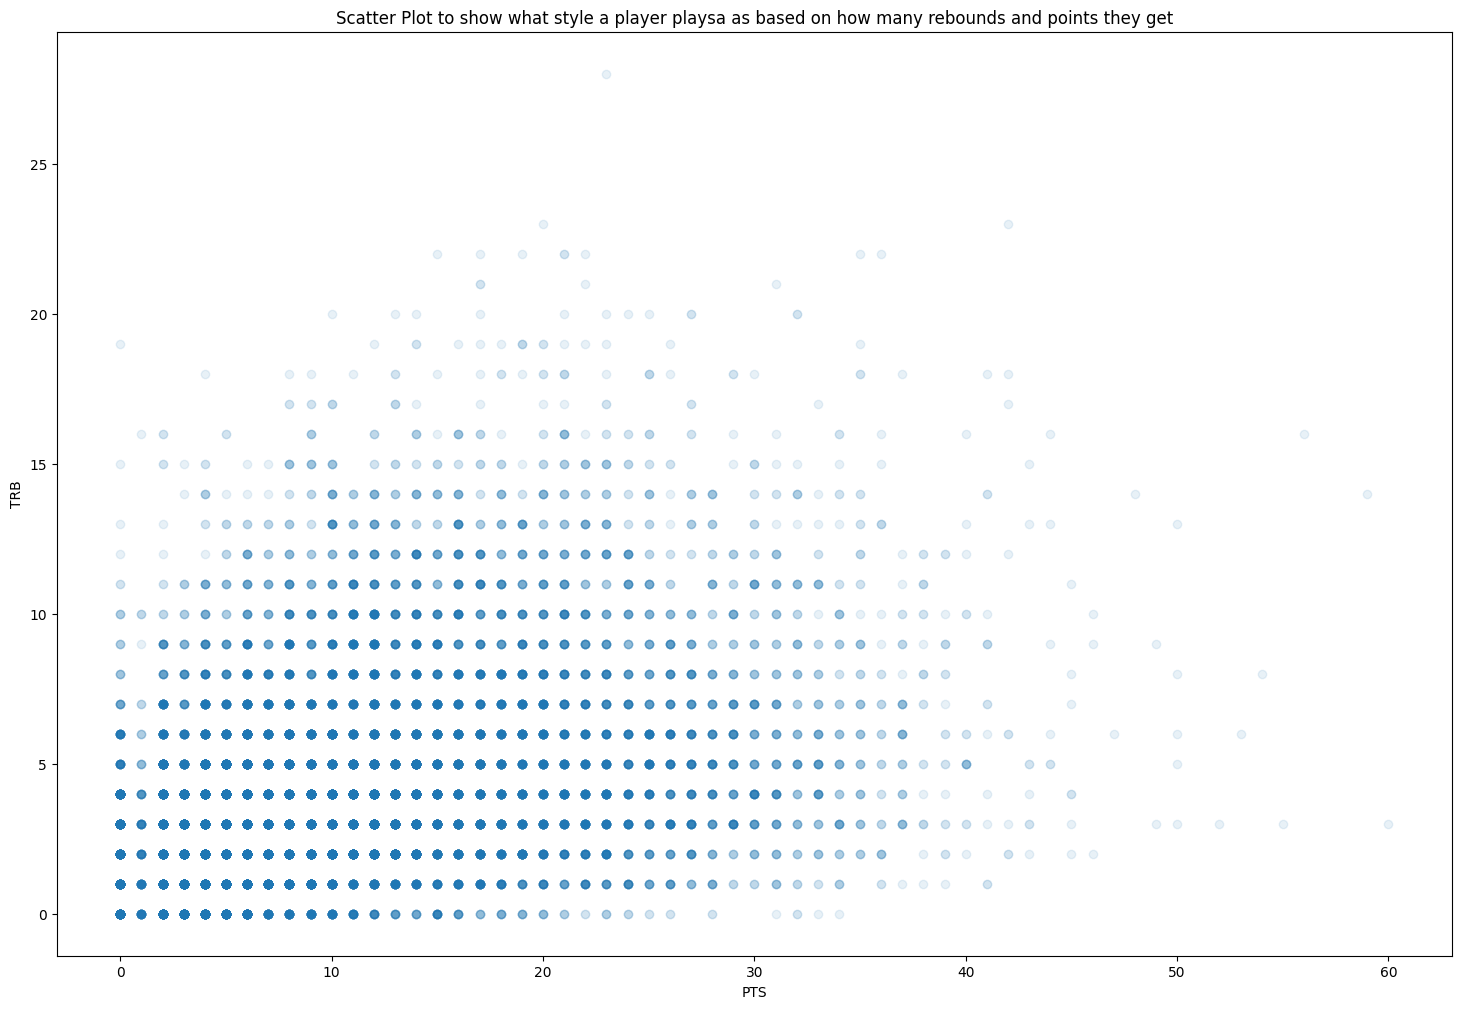

In [15]:
x = df ['PTS']
y = df ['TRB']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('PTS')
plt.ylabel('TRB')
plt.title('Scatter Plot to show what style a player playsa as based on how many rebounds and points they get')

plt.show

Trying to predict the player position looking at the percentage of how many of a players total points are from three pointers

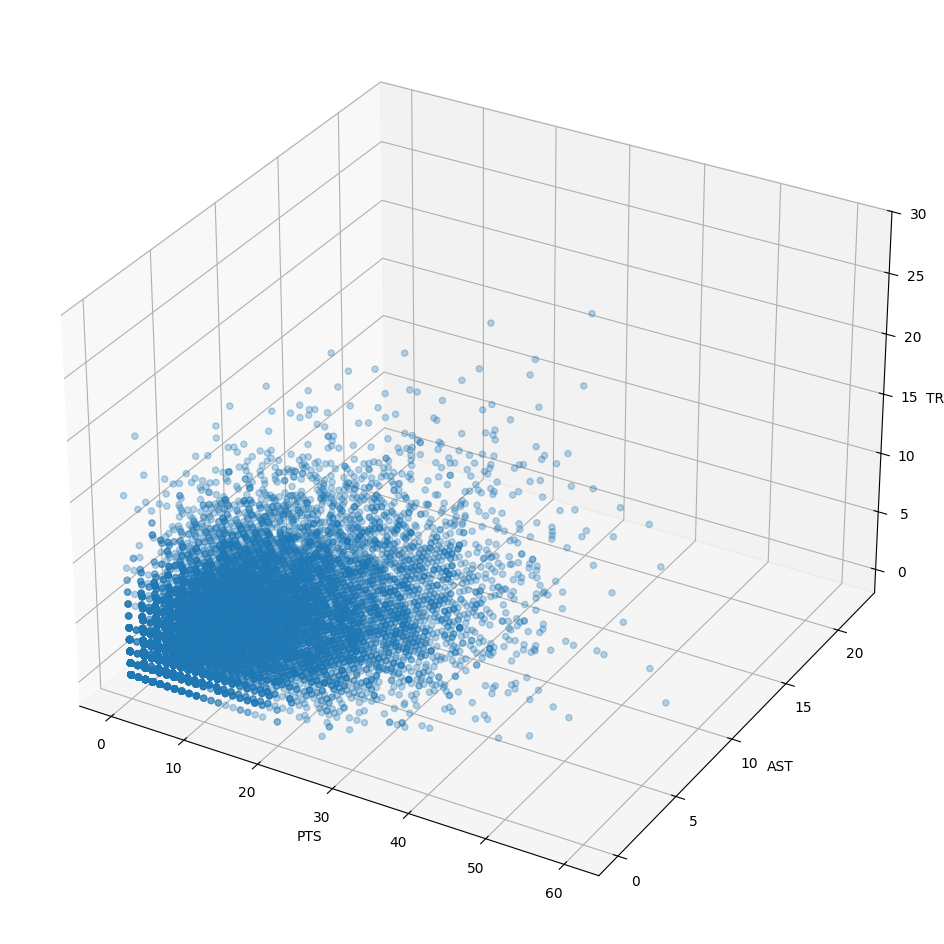

In [19]:


fig = plt.figure(figsize=(18,12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['PTS'], df['AST'], df['TRB'], alpha = 0.3)

ax.set_xlabel('PTS')
ax.set_ylabel('AST')
ax.set_zlabel('TRB')

plt.show()


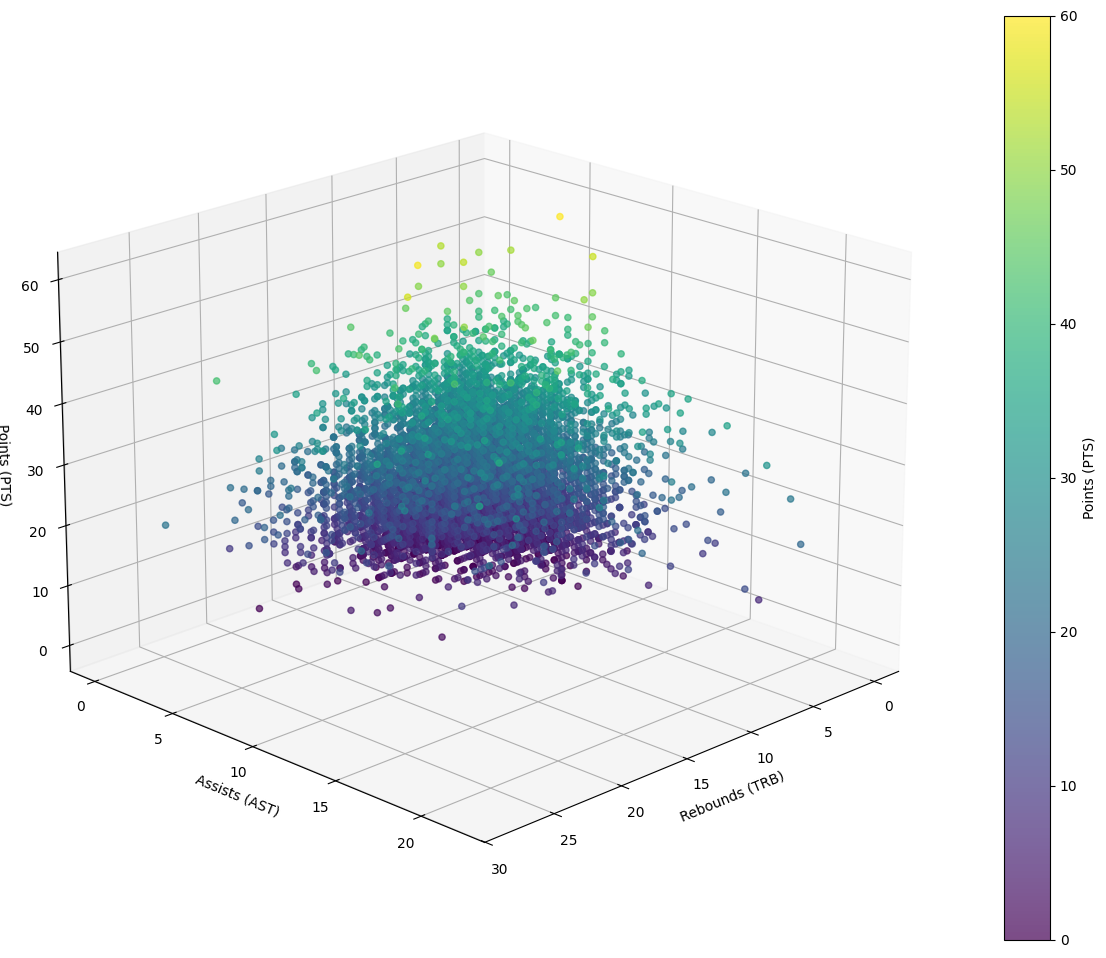

In [27]:
fig = plt.figure(figsize=(18,12))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    df['TRB'],
    df['AST'],
    df['PTS'],
    c=df['PTS'],      # value used for color
    cmap='viridis',   # color scale
    alpha=0.7
)

ax.set_xlabel('Rebounds (TRB)')
ax.set_ylabel('Assists (AST)')
ax.set_zlabel('Points (PTS)')

# Add color bar
cbar = plt.colorbar(sc)
cbar.set_label('Points (PTS)')

# Optional: better viewing angle
ax.view_init(elev=20, azim=45)

plt.show()


New objective: from unlabled datasets, find and categorize players based on their style (assignment is to find what feature best classifies a style) [keep drawing graphs until i find areas of broken data where there are clear defined groups]

<function matplotlib.pyplot.show(close=None, block=None)>

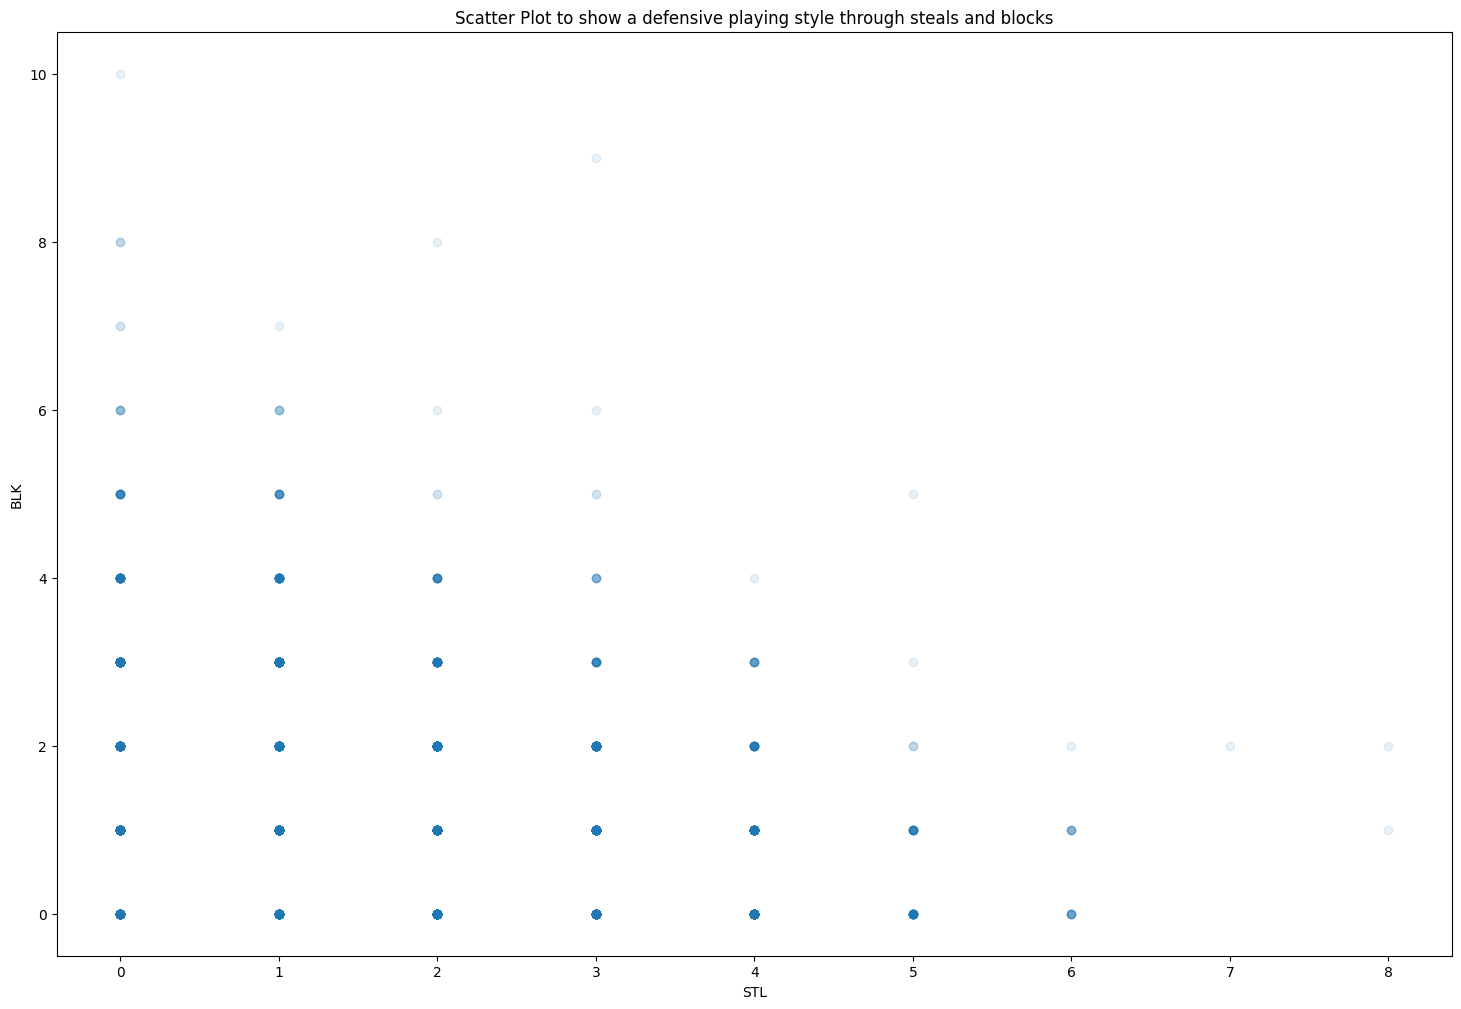

In [28]:
x = df ['STL']
y = df ['BLK']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('STL')
plt.ylabel('BLK')
plt.title('Scatter Plot to show a defensive playing style through steals and blocks')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

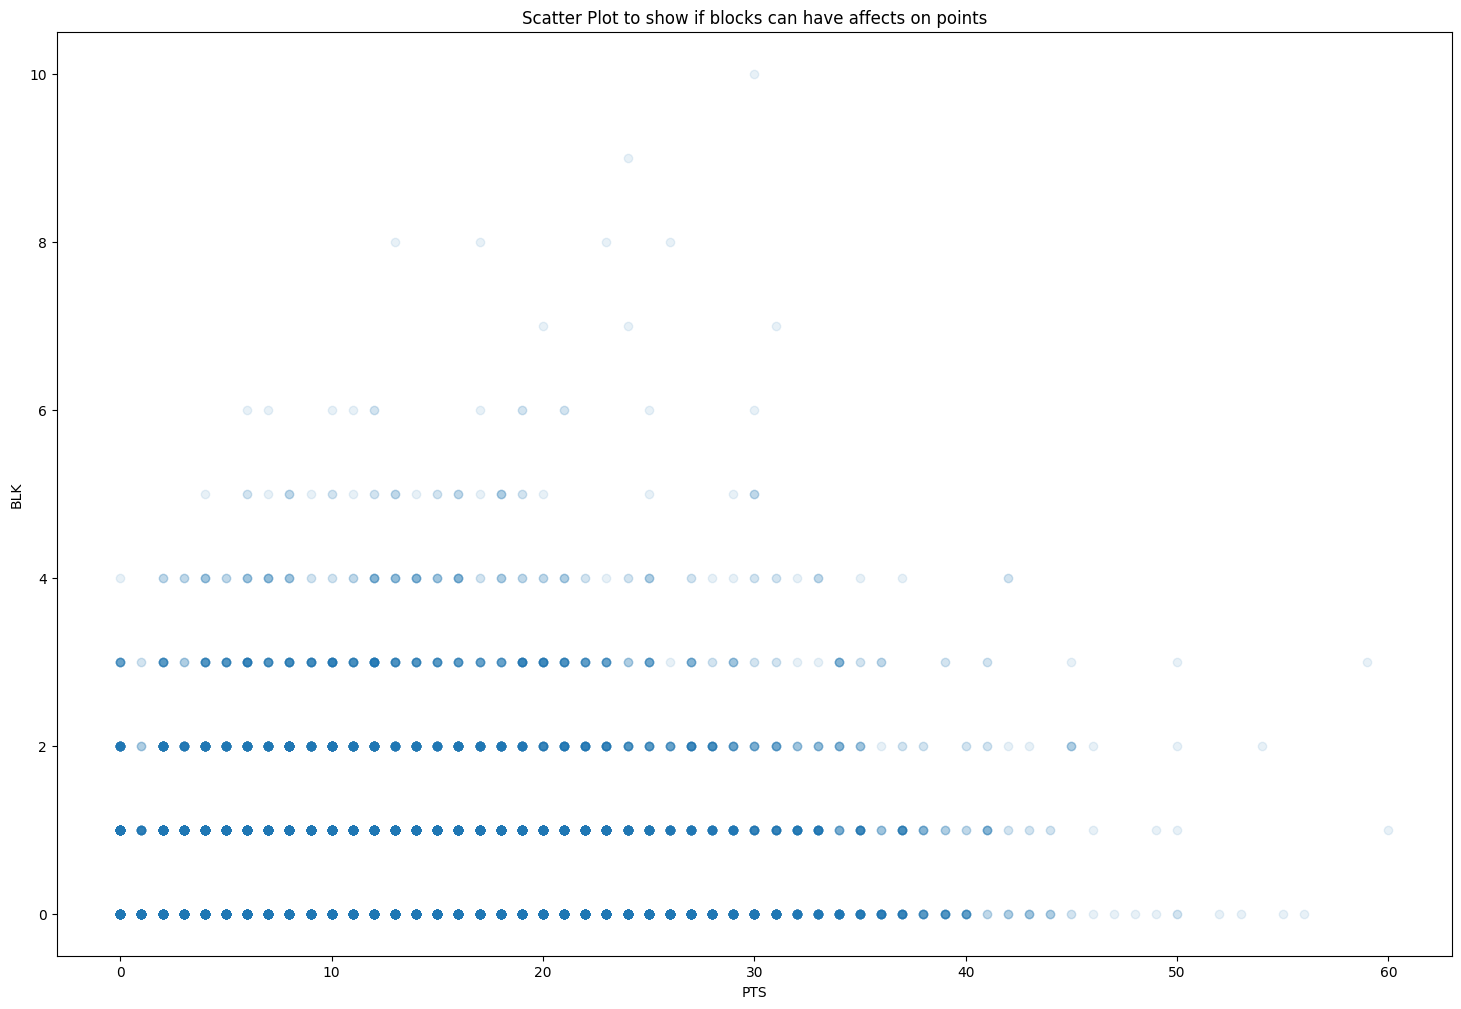

In [29]:
x = df ['PTS']
y = df ['BLK']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('PTS')
plt.ylabel('BLK')
plt.title('Scatter Plot to show if blocks can have affects on points')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

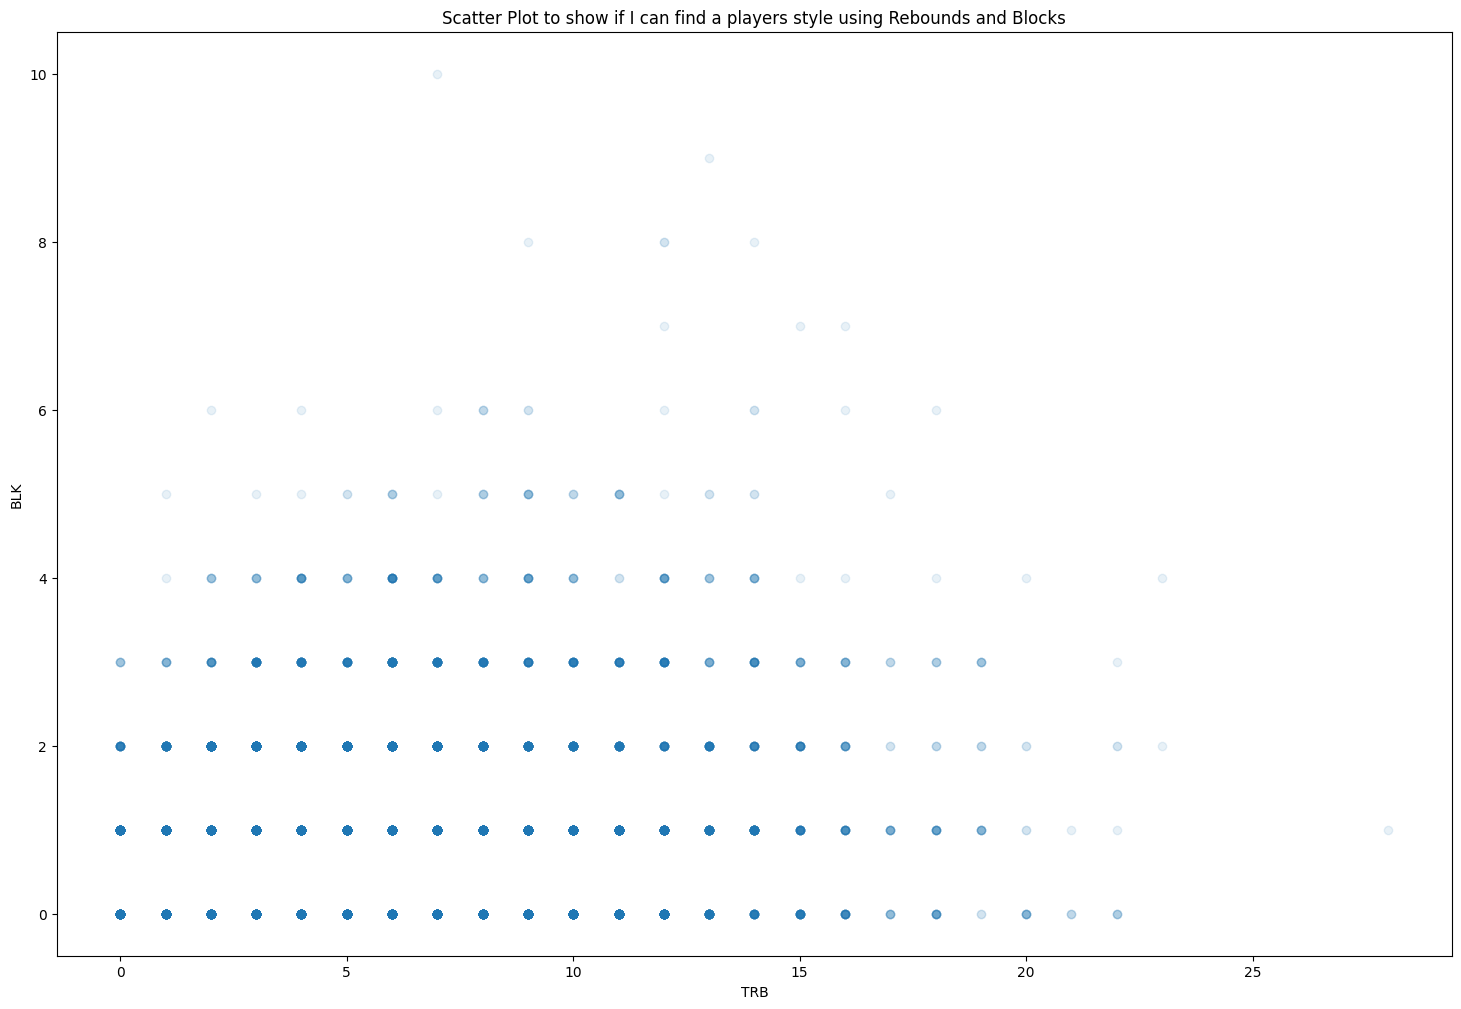

In [30]:
x = df ['TRB']
y = df ['BLK']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('TRB')
plt.ylabel('BLK')
plt.title('Scatter Plot to show if I can find a players style using Rebounds and Blocks')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

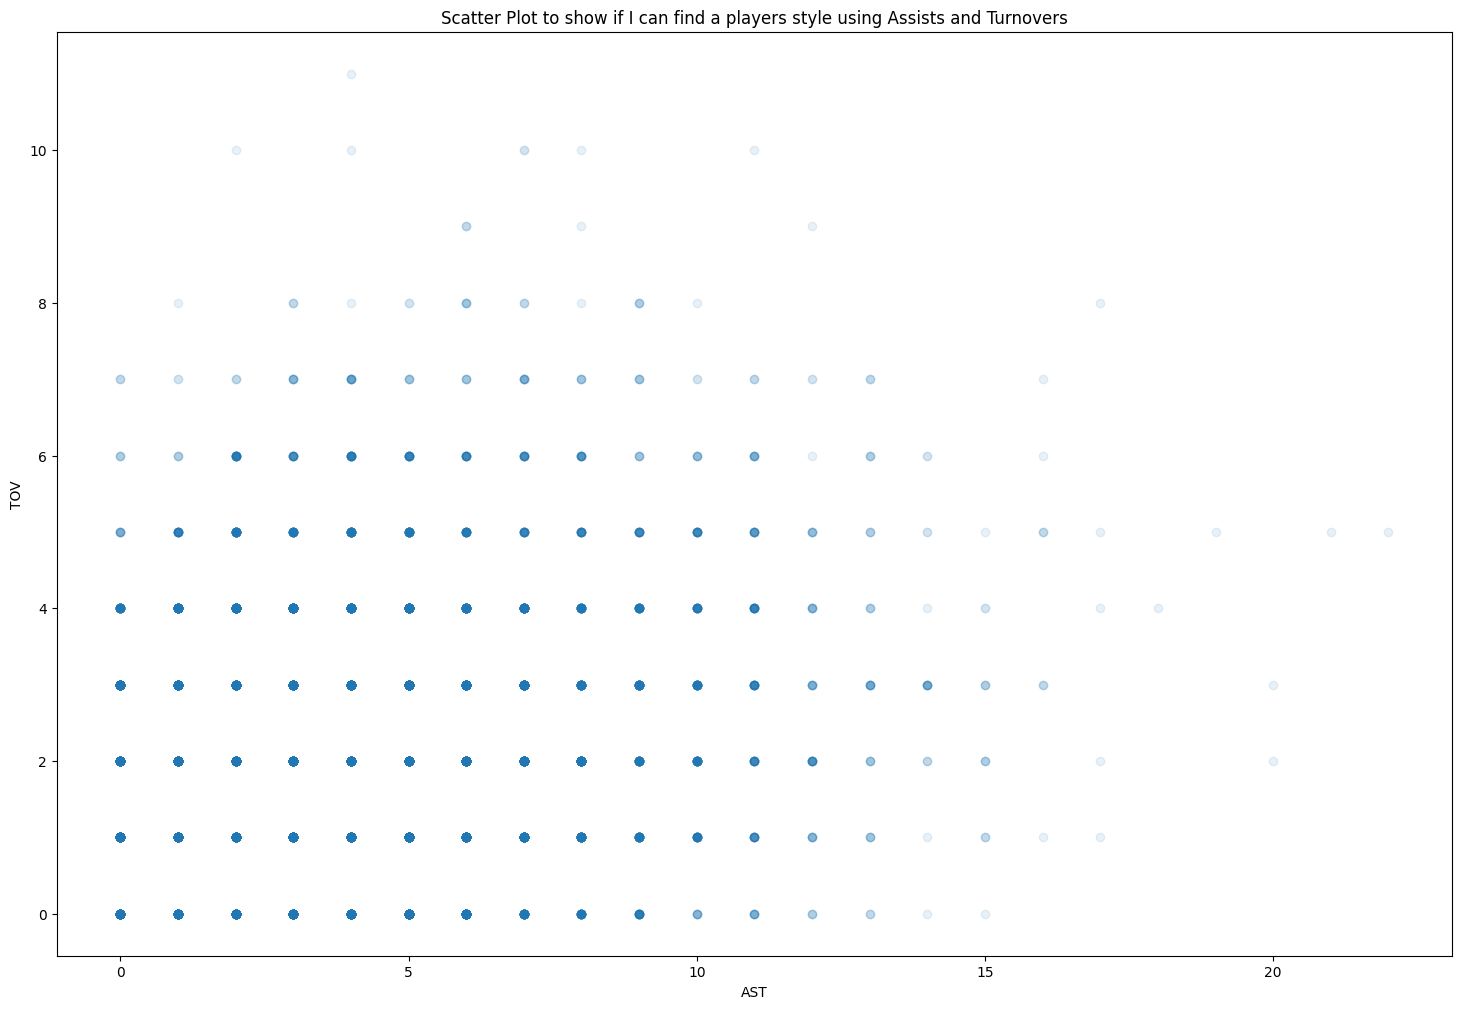

In [31]:
x = df ['AST']
y = df ['TOV']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('AST')
plt.ylabel('TOV')
plt.title('Scatter Plot to show if I can find a players style using Assists and Turnovers')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

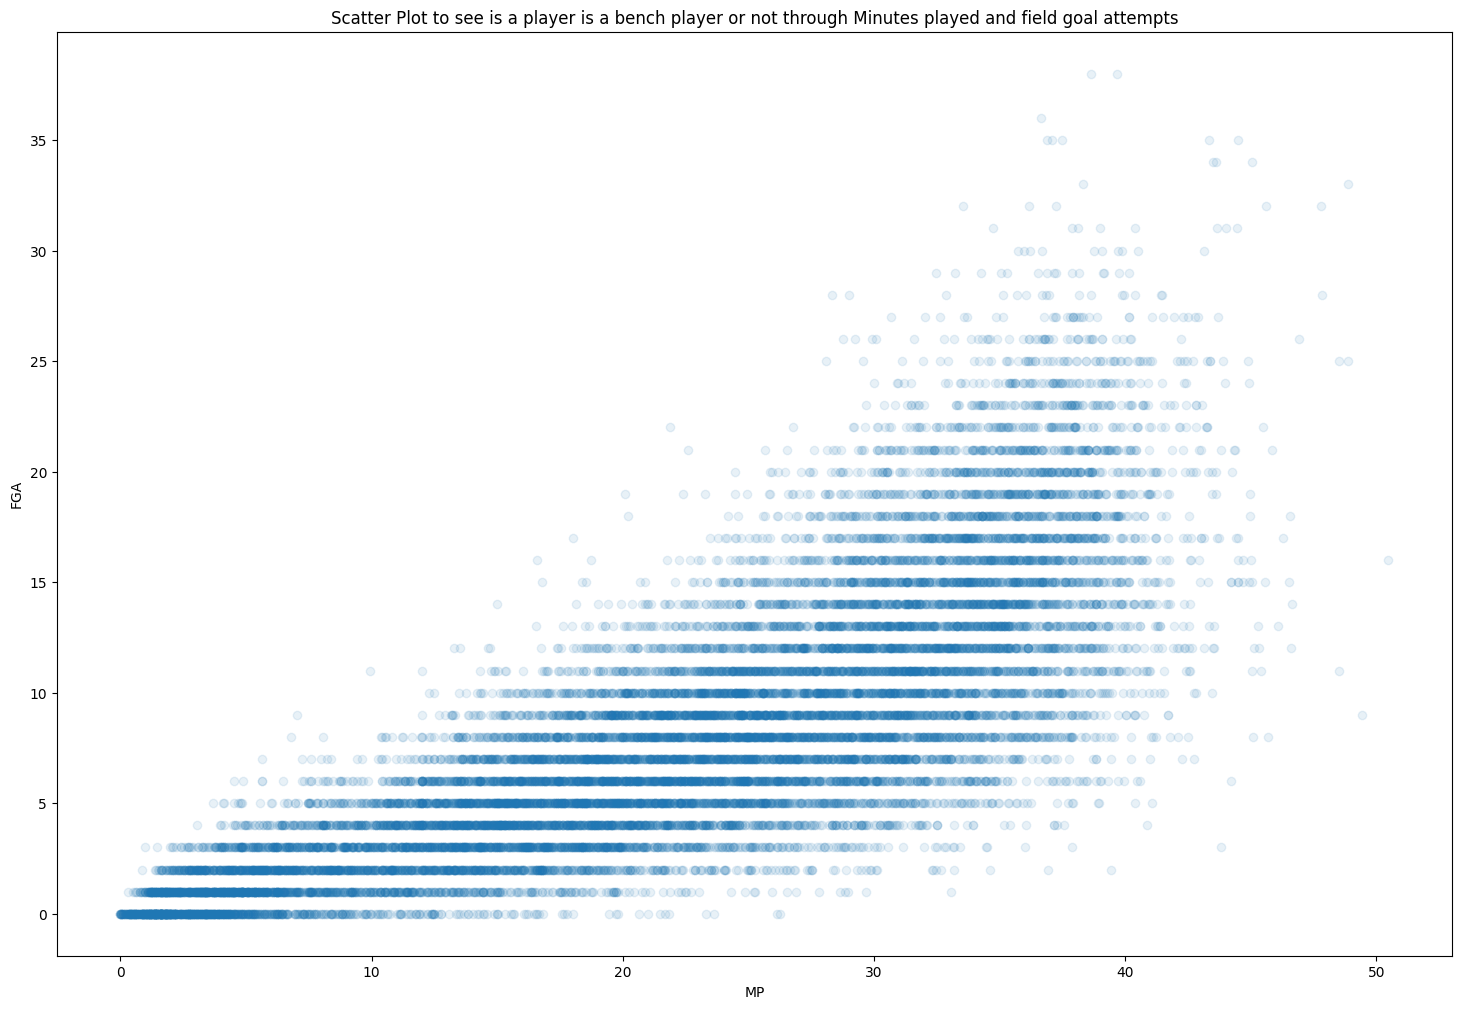

In [33]:
x = df ['MP']
y = df ['FGA']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('MP')
plt.ylabel('FGA')
plt.title('Scatter Plot to see is a player is a bench player or not through Minutes played and field goal attempts')

plt.show

In [ ]:
x = df ['STL']
y = df ['BLK']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('STL')
plt.ylabel('BLK')
plt.title('Scatter Plot to show a defensive playing style through steals and blocks')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

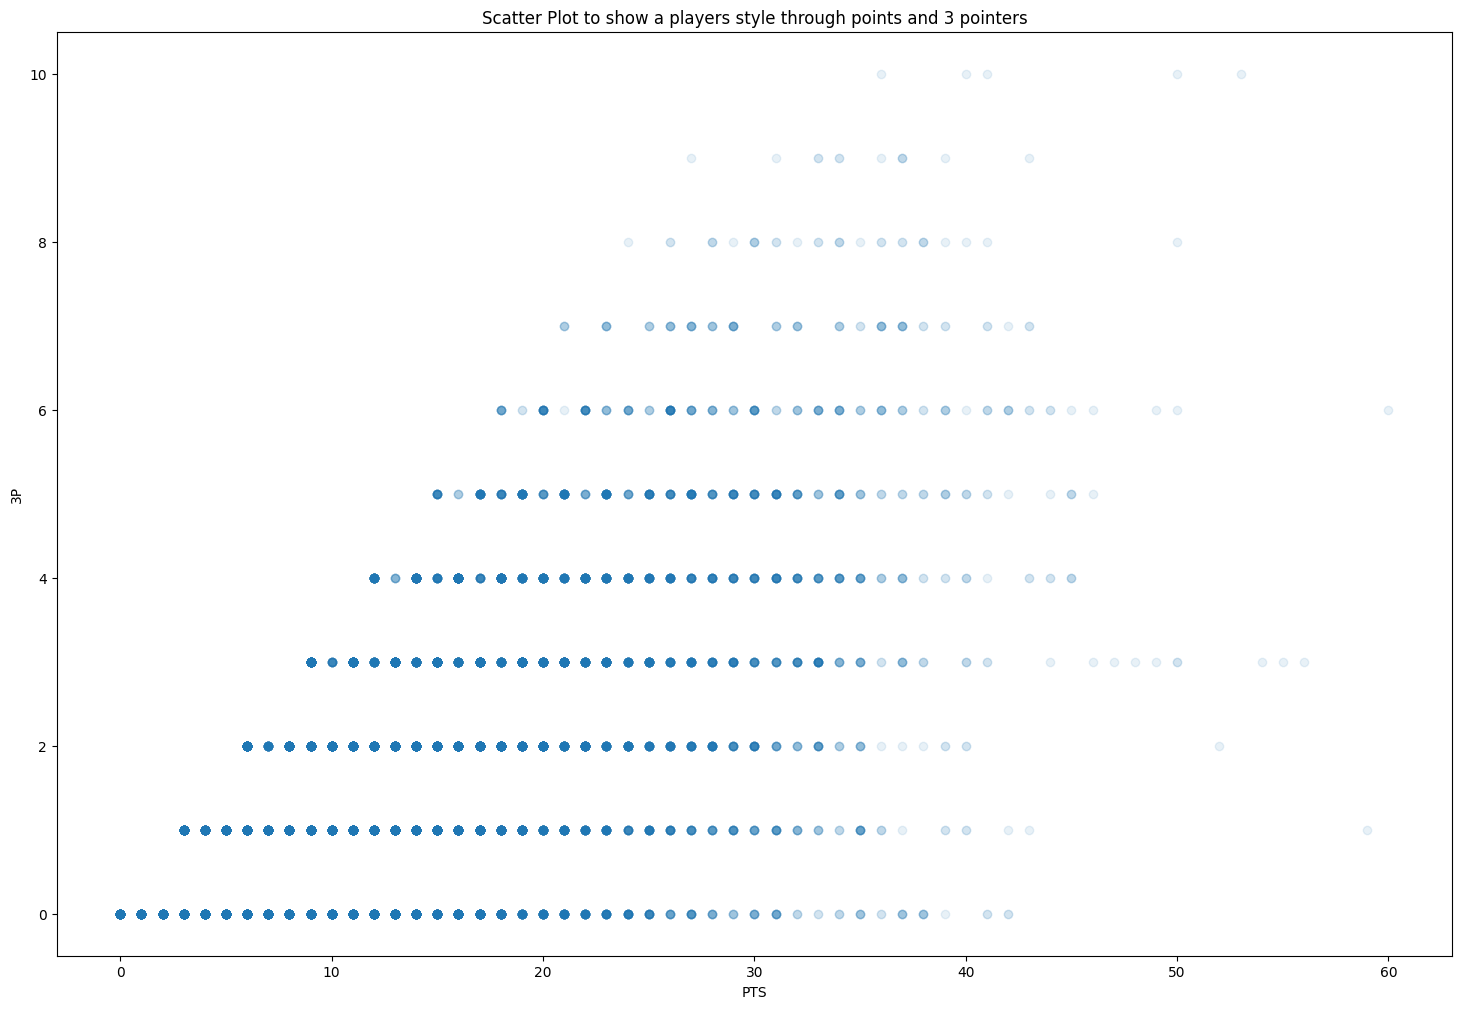

In [34]:
x = df ['PTS']
y = df ['3P']
plt.figure(figsize=(18,12))
plt.scatter(x,y, alpha=0.1)

plt.xlabel('PTS')
plt.ylabel('3P')
plt.title('Scatter Plot to show a players style through points and 3 pointers')

plt.show

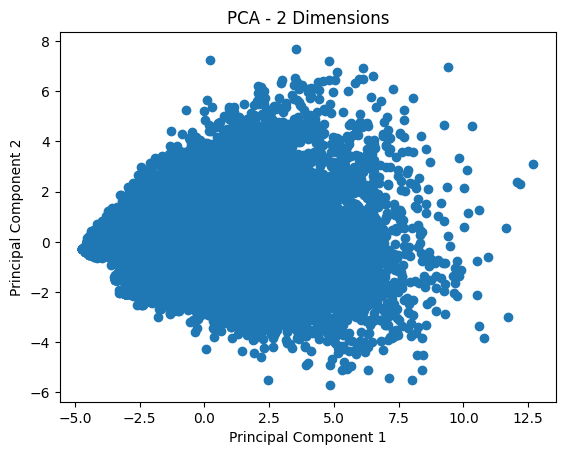

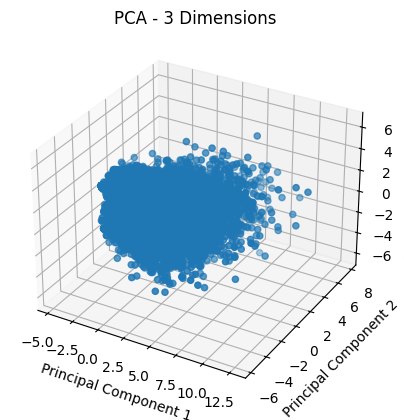

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
df = pd.read_csv("nbadatabase_24_25.csv")

# Keep only numeric columns

df_numeric = df.select_dtypes(include=[np.number])

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# ---------------------------
# 2D PCA
# ---------------------------
pca_2d = PCA(n_components=2)
principal_components_2d = pca_2d.fit_transform(scaled_data)

plt.figure()
plt.scatter(principal_components_2d[:, 0], principal_components_2d[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2 Dimensions")
plt.show()

# ---------------------------
# 3D PCA
# ---------------------------
pca_3d = PCA(n_components=3)
principal_components_3d = pca_3d.fit_transform(scaled_data)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    principal_components_3d[:, 0],
    principal_components_3d[:, 1],
    principal_components_3d[:, 2]
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("PCA - 3 Dimensions")

plt.show()
